[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ashxhuman/Occlusion-effect-on-Model-Performance/blob/main/Occlusion_script.ipynb)

# Effects of Occlusion on Model Performance and Mitigation of These Effects

**A Neuromatch Academy project** — cookiecutter notebook based on the NMA *Example Deep Learning Project* template.

Fill in / adapt each step as the project progresses.

---
# Objectives

We're interested in how **occlusion** (partially hiding an object) affects the performance of image-classification models, and whether **data augmentation** can mitigate these effects. We will use the mammal classes of CIFAR-100, introduce simulated occlusions of different sizes and types (Cutout-style blocks, GridMask), and compare a simple CNN against ResNet18 — trained with and without augmentation.

**Questions (from the project doc):**
1. How does occlusion affect model performance in different types of models?
2. How do the size and type of occlusion contribute to this?
3. How can the effects of occlusion be mitigated?

**Resources**:
* [Paper close to our idea (the one Mohamed sent)](https://arxiv.org/pdf/2409.10775)
* [Occlusion Detection and Handling: A Review](https://www.researchgate.net/publication/278729405_Occlusion_Detection_and_Handling_A_Review)
* [Survey of data-augmentation techniques](https://ieeexplore.ieee.org/abstract/document/10699340)
* [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html)

In [1]:
%pip install torch torchvision numpy scikit-learn matplotlib pandas seaborn -q

Note: you may need to restart the kernel to use updated packages.


---
# Setup

As in the NMA template, we keep the setup cells at the top: Imports, Figure settings, Plotting functions, and Data retrieval.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, transforms
from torchvision.models import resnet18

from sklearn.metrics import confusion_matrix, precision_score
import sklearn.metrics as metrics

import time

from collections import Counter

In [3]:
# @title Figure settings
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")

In [4]:
# @title Set random seed

# @markdown Executing `set_seed(seed=seed)` you are setting the seed

# For DL its critical to set the random seed so that students can have a
# baseline to compare their results to expected results.
# Read more here: https://pytorch.org/docs/stable/notes/randomness.html

# Call `set_seed` function in the exercises to ensure reproducibility.
def set_seed(seed=None, seed_torch=True):
  """
  Function that controls randomness. NumPy and random modules must be imported.

  Args:
    seed : Integer
      A non-negative integer that defines the random state. Default is `None`.
    seed_torch : Boolean
      If `True` sets the random seed for pytorch tensors, so pytorch module
      must be imported. Default is `True`.

  Returns:
    Nothing.
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')


# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

In [5]:
# @title Data retrieval
# @markdown Run this cell to download CIFAR-100 and keep only the mammal classes.

MAMMAL_CLASSES = [
    'fox', 'wolf'
]

cifar_train = torchvision.datasets.CIFAR100(root='./data', train=True, download=True)
cifar_test = torchvision.datasets.CIFAR100(root='./data', train=False, download=True)

label_names = MAMMAL_CLASSES
mammal_ids = [cifar_train.class_to_idx[c] for c in MAMMAL_CLASSES]
old_to_new = {old: new for new, old in enumerate(mammal_ids)}

def filterMammals(dataset):
    images, labels = [], []
    
    # Iterating directly over the dataset/subset yields (image, label) pairs
    for img, lbl in dataset:
        # If the image is already a PIL Image or Tensor, convert to numpy
        if not isinstance(img, np.ndarray):
            img = np.array(img)
            
        if lbl in old_to_new:
            images.append(img)
            labels.append(old_to_new[lbl])
            
    return np.stack(images), np.array(labels)

## splitting test set into 50/50 for validation and test
total_len = len(cifar_test)
train_len = int(0.5 * total_len)
val_len = total_len - train_len
test_set, val_set = torch.utils.data.random_split(cifar_test, [train_len, val_len])

train_images, train_labels = filterMammals(cifar_train)
test_images, test_labels = filterMammals(test_set)
validation_images, validation_labels = filterMammals(val_set)

print('train:', train_images.shape, '  test:', test_images.shape, 'validation:', validation_images.shape)

train: (1000, 32, 32, 3)   test: (98, 32, 32, 3) validation: (102, 32, 32, 3)


In [6]:
import os
from PIL import Image

def save_images_to_folders(images, labels, base_path):
    for idx, (img_arr, label) in enumerate(zip(images, labels)):
        class_dir = os.path.join(base_path, str(label))
        os.makedirs(class_dir, exist_ok=True)
        img = Image.fromarray(img_arr)
        img.save(os.path.join(class_dir, f"{idx}.png"))

save_images_to_folders(train_images, train_labels, './data/train_data')
save_images_to_folders(test_images, test_labels, './data/test_data')

---
# Step 1: Question

**"How does occlusion affect the performance of image-classification models, how do the size and type of the occlusion contribute, and can data augmentation mitigate the effect?"**

Our goal is a *pilot* study: introduce simulated occlusion into CIFAR-100 mammal images, quantify the performance drop for a simple CNN and for ResNet18, and test whether augmentation (including occlusion-like augmentations such as Random Erasing) makes the models more robust.

Possible extensions (from the project doc): Faster R-CNN on regular / occluded / augmented data, effects of masks or segmentation and other models (e.g. YOLO), and occlusion of specific body parts using DeepLabCut.

---
# Step 2: literature review

Most importantly, our literature review needs to address the following:

1. **What techniques help to reduce the effects of occlusion?**
   * https://arxiv.org/pdf/2409.10775 (the one that Mohamed sent)
2. **What are the types of occlusion?**
   * *Naturally occurring*: self-occlusion, inter-object occlusion, scene occlusion, object truncation.
   * *Simulated*: deliberately introduced for training/augmentation —
     * single-region synthetic block removal: **Cutout**, **Random Erasing**
     * multi-region structured removal: **GridMask**, **Hide-and-Seek**
3. **What types of occlusion have the most severe consequences for computer-vision models?**
   * [Occlusion Detection and Handling: A Review](https://www.researchgate.net/publication/278729405_Occlusion_Detection_and_Handling_A_Review)
4. **What types of augmentation strategies could we use?**
   * Survey: https://ieeexplore.ieee.org/abstract/document/10699340
   * *Geometric*: rotation, translation, shearing, flipping
   * *Non-geometric*: cropping/resizing, noise injection, color space, jitter, kernel filters
   * *Image erasing*: Cutout, Random Erasing, **Hide-and-Seek** (particularly effective against occlusion), GridMask
   * *Advanced*: LocalAugment, SelfAugmentation, SalfMix, KeepAugment, YOCO, Cut-Thumbnail, Mixup, ...
5. The effects of occlusion on the (human) visual system and how occlusion reasoning develops.

---
# Step 3: ingredients

## Data ingredients

After the data retrieval cell we have 4 numpy arrays plus label names:

- `train_images`: 2500 training images (5 classes x 500), shape 32x32x3, uint8
- `train_labels`: class labels (0-5) for the training images
- `test_images`: 241 test images (50:50 ratio)
- `test_labels`: class labels for the test images
- `label_names`: text names of the 5 mammal classes

Let's have a quick look at the data:

In [7]:
print(train_images.shape, train_images.dtype)
print(test_images.shape)

# class balance:
print(Counter(train_labels))
print(Counter(test_labels))

(1000, 32, 32, 3) uint8
(98, 32, 32, 3)
Counter({np.int64(1): 500, np.int64(0): 500})
Counter({np.int64(1): 52, np.int64(0): 46})


In [8]:
## Train model to detect fox out of 5 animal class

class FoxDetectorCNN(nn.Module):
    def __init__(self):
        super(FoxDetectorCNN, self).__init__()
        # First layer: 3 input channels -> 16 output channels. Output size: 16 x 32 x 32
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1), 
            nn.ReLU()
        )
        
        # Extra layer: 16 input channels -> 32 output channels. Output size: 32 x 32 x 32
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # Fully connected layer: Updated to reflect the 32 channels from layer2
        self.fc = nn.Linear(32 * 32 * 32, 1)
        self.nl = nn.Identity()

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)  # Pass the feature maps through the extra layer
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.nl(out)
        return out

In [9]:
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"using device: {device}")

# 1. Instantiate the model and send it to your device (GPU/MPS/CPU)
model = FoxDetectorCNN().to(device)

# 2. Use Binary Cross Entropy for single-output binary classification
criterion = nn.BCEWithLogitsLoss()

# 3. Setup optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

using device: mps


In [10]:
# 1. Prepare data loader from raw numpy arrays
tensor_x = torch.Tensor(train_images).permute(0, 3, 1, 2)
tensor_y = torch.Tensor(train_labels)
train_dataset = torch.utils.data.TensorDataset(tensor_x, tensor_y)
train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)

# Prepare validation data loader
tensor_valid_x = torch.Tensor(validation_images).permute(0, 3, 1, 2)
tensor_valid_y = torch.Tensor(validation_labels)
valid_dataset = torch.utils.data.TensorDataset(tensor_valid_x, tensor_valid_y)
valid_loader = DataLoader(dataset=valid_dataset, batch_size=128, shuffle=False) # Typically False for validation

# 2. Set tracking parameters and run training loop
num_epochs = 10
loss_list = []
acc_list = []

# --- TRACK BEST ACCURACY ---
best_valid_acc = 0.0
# ---------------------------

for epoch in range(num_epochs):
    model.train() # Ensure model is in train mode at the start of epoch
    correct = 0
    total = 0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        
        # Map original target label index 0 (fox) to 1.0, and all others to 0.0
        binary_labels = (labels == 0).float().unsqueeze(1).to(device)
        
        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, binary_labels)
        loss_list.append(loss.item())
        
        # 2. Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 3. Track training accuracy
        predictions = (outputs > 0).float()
        correct += (predictions == binary_labels).sum().item() # Fixed: use += to accumulate over batches
        total += binary_labels.size(0) # Fixed: use += to accumulate over batches

    print(f"Epoch [{epoch + 1}/{num_epochs}], "
          f"Loss: {loss.item():.4f}, "
          f"Train Accuracy: {((correct / total) * 100):.2f}%")
    
    # Validation phase
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():  # Turn off gradient tracking
        for images, labels in valid_loader:
            images = images.to(device)
            binary_labels = (labels == 0).float().unsqueeze(1).to(device)
            
            outputs = model(images)
            predictions = (outputs > 0).float()
            
            total += binary_labels.size(0)
            correct += (predictions == binary_labels).sum().item()
    
    test_accuracy = (correct / total) * 100
    print(f"Valid Accuracy for Fox Detector: {test_accuracy:.2f}%")
    
    # --- SAVE BEST MODEL CHECKPOINT ---
    if test_accuracy > best_valid_acc:
        best_valid_acc = test_accuracy
        torch.save(model.state_dict(), 'fox_detector_best.pth')
        print(f"--> New best model saved with Val Accuracy: {best_valid_acc:.2f}%")
    # ----------------------------------

Epoch [1/10], Loss: 1.2089, Train Accuracy: 52.50%
Valid Accuracy for Fox Detector: 60.78%
--> New best model saved with Val Accuracy: 60.78%
Epoch [2/10], Loss: 0.5746, Train Accuracy: 55.50%
Valid Accuracy for Fox Detector: 59.80%
Epoch [3/10], Loss: 0.7150, Train Accuracy: 54.50%
Valid Accuracy for Fox Detector: 47.06%
Epoch [4/10], Loss: 0.6206, Train Accuracy: 56.60%
Valid Accuracy for Fox Detector: 61.76%
--> New best model saved with Val Accuracy: 61.76%
Epoch [5/10], Loss: 0.5247, Train Accuracy: 70.30%
Valid Accuracy for Fox Detector: 66.67%
--> New best model saved with Val Accuracy: 66.67%
Epoch [6/10], Loss: 0.4169, Train Accuracy: 77.50%
Valid Accuracy for Fox Detector: 71.57%
--> New best model saved with Val Accuracy: 71.57%
Epoch [7/10], Loss: 0.3727, Train Accuracy: 82.30%
Valid Accuracy for Fox Detector: 75.49%
--> New best model saved with Val Accuracy: 75.49%
Epoch [8/10], Loss: 0.3625, Train Accuracy: 86.90%
Valid Accuracy for Fox Detector: 76.47%
--> New best mode

In [11]:
# 1. Prepare test data loader from raw numpy arrays
tensor_test_x = torch.Tensor(test_images).permute(0, 3, 1, 2)
tensor_test_y = torch.Tensor(test_labels)
test_dataset = torch.utils.data.TensorDataset(tensor_test_x, tensor_test_y)
test_loader = DataLoader(dataset=test_dataset, batch_size=128, shuffle=False)

# 1. Load the specific Epoch 4 weights
model.load_state_dict(torch.load('fox_detector_best.pth', map_location=device))
print("Loaded Epoch 4 model weights successfully.")

# 2. Evaluation loop
model.eval()  # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # Turn off gradient tracking
    for images, labels in test_loader:
        images = images.to(device)
        
        # Map original target label index 0 (fox) to 1.0, and all others to 0.0
        binary_labels = (labels == 0).float().unsqueeze(1).to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Positive logit (> 0) means predicting "Fox" (1), negative means "Not Fox" (0)
        predictions = (outputs > 0).float()
        
        # Track accuracy
        total += binary_labels.size(0)
        correct += (predictions == binary_labels).sum().item()

test_accuracy = (correct / total) * 100
print(f"Test Accuracy for Fox Detector: {test_accuracy:.2f}%")

Loaded Epoch 4 model weights successfully.
Test Accuracy for Fox Detector: 77.55%


In [12]:

# 1. Prepare data loader from raw numpy arrays
valid_tensor_x = torch.Tensor(validation_images).permute(0, 3, 1, 2)
valid_tensor_y = torch.Tensor(validation_labels)
train_dataset = torch.utils.data.TensorDataset(valid_tensor_x, valid_tensor_y)
train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)

# 2. Evaluation loop
model.eval()  # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # Turn off gradient tracking
    for images, labels in test_loader:
        images = images.to(device)
        
        # Map original target label index 0 (fox) to 1.0, and all others to 0.0
        binary_labels = (labels == 0).float().unsqueeze(1).to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Positive logit (> 0) means predicting "Fox" (1), negative means "Not Fox" (0)
        predictions = (outputs > 0).float()
        
        # Track accuracy
        total += binary_labels.size(0)
        correct += (predictions == binary_labels).sum().item()

test_accuracy = (correct / total) * 100
print(f"Validation Accuracy for Fox Detector: {test_accuracy:.2f}%")

Validation Accuracy for Fox Detector: 77.55%


In [13]:
# 1. Load the specific Epoch 4 weights
model.load_state_dict(torch.load('fox_detector_epoch4.pth', map_location=device))
print("Loaded Epoch 4 model weights successfully.")

def evaluateModelBinary(model, data_loader):
    model.eval()
    real_labels, predicted_labels = [], []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            # Map original target label index 0 (fox) to 1.0, and all others to 0.0
            binary_labels = (labels == 0).float().unsqueeze(1).to(device)
            
            outputs = model(images)
            # Positive logit (> 0) means predicting "Fox" (1), negative means "Not Fox" (0)
            predictions = (outputs > 0).float()
            
            total += binary_labels.size(0)
            correct += (predictions == binary_labels).sum().item()
            
            # Store for precision calculation if needed
            real_labels.extend(binary_labels.cpu().numpy().flatten())
            predicted_labels.extend(predictions.cpu().numpy().flatten())
            
    accuracy = (correct / total) * 100
    precision = precision_score(real_labels, predicted_labels, zero_division=0) * 100
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'real_labels': real_labels,
        'predicted_labels': predicted_labels
    }

# --- Evaluate on Clean Test Dataset ---
clean_results = evaluateModelBinary(model, test_loader)
print(f"CLEAN test:      accuracy {clean_results['accuracy']:.2f}%, precision {clean_results['precision']:.2f}%")

Loaded Epoch 4 model weights successfully.
CLEAN test:      accuracy 84.69%, precision 79.25%


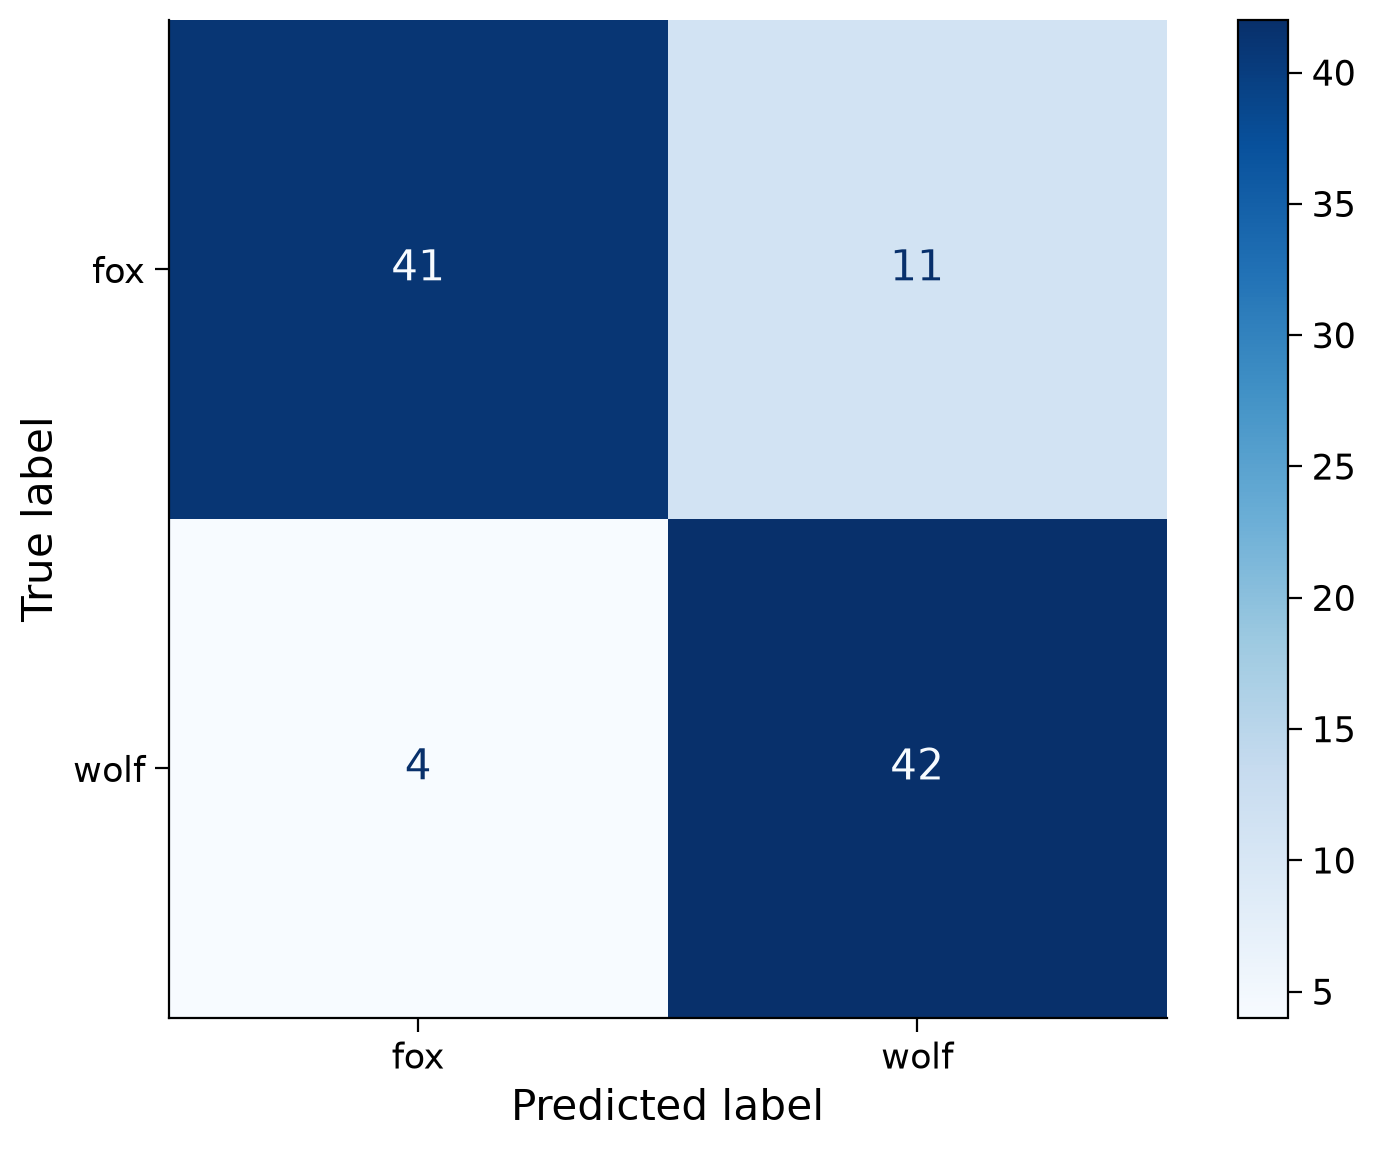

In [14]:
def plotConfusionMatrix(real_labels, predicted_labels, class_names):
    cm = metrics.confusion_matrix(real_labels, predicted_labels)
    metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.show()

plotConfusionMatrix(clean_results['real_labels'], clean_results['predicted_labels'], label_names)

## Occlusion ingredients

We simulate occlusion at the pixel level. Sizes are defined on the 32x32 CIFAR images:

Types:
- **Cutout** (Cutout-style): one random square region filled with a constant value
- **Mixup**: a regular grid of masked cells (structured, multi-region)

## Cutout

In [15]:
# hyper-parameters
use_cuda = torch.cuda.is_available()
alpha = 1  # alpha for mixup augmentation
best_acc = 0  # best test accuracy
start_epoch = 0  # start from epoch 0 or last checkpoint epoch
batch_size = 128
end_apochs = 200  # Please change this to 200
base_learning_rate = 0.1
cutout = True  # True/False if you want to use cutout augmentation
mixup = False  # True/False if you want to use mixup augmentation
n_holes = 1  # number of holes to cut out from image for cutout
length = 16  # length of the holes for cutout augmentation
torchvision_transforms = False # True/False if you want use torchvision augmentations

In [16]:
# @markdown `Cutout` Augmentation class

class Cutout(object):
  """
  code from: https://github.com/uoguelph-mlrg/Cutout

  Randomly mask out one or more patches from an image.
  Args:
      n_holes (int): Number of patches to cut out of each image.
      length (int): The length (in pixels) of each square patch.
  """
  def __init__(self, n_holes, length):
    self.n_holes = n_holes
    self.length = length

  def __call__(self, img):
    """
    Args:
        img (Tensor): Tensor image of size (C, H, W).
    Returns:
        Tensor: Image with n_holes of dimension length x length cut out of it.
    """
    h = img.size(1)
    w = img.size(2)

    mask = np.ones((h, w), np.float32)

    for n in range(self.n_holes):
      y = np.random.randint(h)
      x = np.random.randint(w)

      y1 = np.clip(y - self.length // 2, 0, h)
      y2 = np.clip(y + self.length // 2, 0, h)
      x1 = np.clip(x - self.length // 2, 0, w)
      x2 = np.clip(x + self.length // 2, 0, w)

      mask[y1: y2, x1: x2] = 0.

    mask = torch.from_numpy(mask)
    mask = mask.expand_as(img)
    img = img * mask

    return img

## Mixup

In [17]:
# @markdown `mixup_data` Augmentation function

def mixup_data(x, y, alpha=1.0, use_cuda=True):
  '''Compute the mixup data. Return mixed inputs, pairs of targets, and lambda
      - https://github.com/hongyi-zhang/mixup
  '''
  if alpha > 0.:
    lam = np.random.beta(alpha, alpha)
  else:
    lam = 1.
  batch_size = x.size()[0]
  if use_cuda:
    index = torch.randperm(batch_size).cuda()
  else:
    index = torch.randperm(batch_size)

  mixed_x = lam * x + (1 - lam) * x[index, :]
  y_a, y_b = y, y[index]

  return mixed_x, y_a, y_b, lam

In [18]:

mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

# Build transforms
transform_train_list = []
if torchvision_transforms:
    transform_train_list.append(transforms.RandomCrop(32, padding=4))
    transform_train_list.append(transforms.RandomHorizontalFlip())

transform_train_list.append(transforms.ToTensor())
transform_train_list.append(transforms.Normalize(mean, std))

if cutout:
    transform_train_list.append(Cutout(n_holes=n_holes, length=length))

transform_train = transforms.Compose(transform_train_list)

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = datasets.ImageFolder(root='./data/train_data', transform=transform_train)
test_dataset = datasets.ImageFolder(root='./data/test_data', transform=transform_test)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

Let's make sure the occlusion functions do what we intended:

In [19]:
# get batch of data
batch_X, batch_Y =  next(iter(train_loader))

In [20]:
def plot_mixed_images(images):
  inv_normalize = transforms.Normalize(
                      mean= [-m/s for m, s in zip(mean, std)],
                      std= [1/s for s in std]
                      )
  inv_PIL = transforms.ToPILImage()
  fig = plt.figure(figsize=(10, 8))
  for i in range(1, len(images) + 1):
    image = images[i-1]
    ax = fig.add_subplot(1, 4, i)
    inv_tensor = inv_normalize(image).cpu()
    ax.imshow(inv_PIL(inv_tensor))
    plt.show()

In [21]:
# Mixup Visualization
if mixup:
  alpha = 0.9
  mixed_x, y_a, y_b, lam = mixup_data(batch_X, batch_Y,
                                      alpha=alpha, use_cuda=use_cuda)
  plot_mixed_images(mixed_x[:4])

In [22]:
if torchvision_transforms:
  plot_mixed_images(batch_X[:4])

## Model ingredients

**"Mechanisms"**:

* Occlusion? --> Simulated, pixel-level, applied on-the-fly in the dataset object so every epoch sees different occlusion locations. We vary **size** (small/medium/large) and **type** (block/gridmask).

* Augmentation (the mitigation)? --> Standard geometric augmentation (random crop with padding, horizontal flip) plus **Random Erasing**, an occlusion-like augmentation which the literature suggests improves robustness to occlusion.

* Classifiers? --> A simple CNN (baseline), taking the best model on validation set.

* Input? --> 32x32x3 CIFAR-100 mammal images, normalized; occluded or not, augmented or not.

* Output? --> 5 class probabilities; we take the argmax and evaluate with **accuracy, per-class precision and the confusion matrix**.

---
# Step 4: hypotheses

* **Hypothesis 1**: Occlusion reduces model performance, visible as more confusion in the confusion matrix and lower precision; larger occlusions hurt more.
  * *Null hypothesis*: occlusion does not change performance (no change in confusion matrix or precision).

* **Hypothesis 2**: Augmentation reduces the effect of occlusion on model performance (recovers part of the lost precision / cleans up the confusion matrix).
  * *Null hypothesis*: augmentation does not change performance on occluded data.

* **Hypothesis 3**: ResNet18 performs better than the simple CNN, even with occlusion.
  * *Null hypothesis*: the models perform equally well.

In mathematical terms:
* Hypothesis 1: $\mathbb{E}(perf_{clean}) > \mathbb{E}(perf_{occluded})$, and $perf$ decreases with occlusion size
* Hypothesis 2: $\mathbb{E}(perf_{occluded+aug}) > \mathbb{E}(perf_{occluded})$
* Hypothesis 3: $\mathbb{E}(perf_{ResNet18}) > \mathbb{E}(perf_{CNN})$ for every condition

---
# Step 5: toolkit selection

We need a toolkit that can classify images. We keep it as simple as possible:

* **PyTorch + torchvision**: CIFAR-100 download, transforms (augmentation)
* A small **2D convnet** written by us as the baseline model.
* **scikit-learn** for the confusion matrix and precision scores.

This allows us to answer our question (performance under occlusion), speaks to our hypotheses (model comparison, augmentation mitigation), and is feasible in NMA project time. Training is much faster on a GPU — in Colab, set `Runtime > Change runtime type > GPU`.

---
# Step 6: model drafting

Our sketch of the experiment pipeline:

```
                 +--------------------+
CIFAR-100        |  occlusion (none / |        +-----------+
mammals   -----> |  small / medium /  | -----> | augment?  | -----> CNN or ResNet18 -----> 25 classes
(32x32x3)        |  large / gridmask) |        | (yes/no)  |
                 +--------------------+        +-----------+
```

Experiment grid (Steps 1-5 of the project doc):

| # | model    | training data | augmentation |
|---|----------|---------------|--------------|
| 1 | CNN      | regular       | no           |
| 2 | CNN      | occluded      | no           |
| 3 | ResNet18 | regular       | no           |
| 4 | ResNet18 | occluded      | no           |
| 5a| CNN      | occluded      | yes          |
| 5b| ResNet18 | occluded      | yes          |

Each trained model is evaluated on **both** the clean and the occluded test set.

---
# Step 7: model implementation

It's finally time to write some deep learning code... so here we go!

The cell below creates a `Dataset` object class (based on the PyTorch data tutorial, like in the NMA example project). We can tell the dataset object to use the training or test data, whether to apply **occlusion** (and which kind), and whether to apply **augmentation**:

We want to make sure that this object works the way we intended, so we try it out:

In [23]:
mammals_train = train_dataset
mammals_test_occ = test_dataset

print('TRAINING:', len(mammals_train))
x, y = mammals_train[0]
print(x.shape, label_names[y])

print('\nTESTING (occluded):', len(mammals_test_occ))
x, y = mammals_test_occ[0]
print(x.shape, label_names[y])

TRAINING: 1000
torch.Size([3, 32, 32]) fox

TESTING (occluded): 211
torch.Size([3, 32, 32]) fox


## Build models

PyTorch expects a minibatch of B samples as input, so a 2D CNN gets a 4D tensor: **BxCxHxW**

- **B:** batch size
- **C:** channels (3 color channels)
- **H, W:** height and width (32x32)

First the simple baseline CNN (2 conv blocks + 2 fully connected layers), then a helper that builds a fresh (not pretrained) ResNet18 adapted to 32x32 inputs:

In [24]:
# class MammalCNN(nn.Module):
#   """Simple baseline 2D convnet for 32x32 images, 25 classes."""

#   def __init__(self, num_classes=25):
#     super(MammalCNN, self).__init__()

#     self.layer1 = nn.Sequential(
#         nn.Conv2d(3, 32, kernel_size=3, padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(kernel_size=2, stride=2))  # -> 32x16x16

#     self.layer2 = nn.Sequential(
#         nn.Conv2d(32, 64, kernel_size=3, padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(kernel_size=2, stride=2))  # -> 64x8x8

#     self.dropout1 = nn.Dropout(p=0.2
#     self.fc1 = nn.Linear(64 * 8 * 8, 512)
#     self.nl = nn.ReLU()
#     self.dropout2 = nn.Dropout(p=0.2)
#     self.fc2 = nn.Linear(512, num_classes)

#   def forward(self, x):
#     out = self.layer1(x)
#     out = self.layer2(out)

#     out = out.reshape(out.size(0), -1)
#     out = self.dropout1(out)
#     out = self.fc1(out)
#     out = self.nl(out)
#     out = self.dropout2(out)
#     out = self.fc2(out)
#     out = nn.functional.log_softmax(out, dim=1)

#     return out


# def makeResNet18(num_classes=25):
#   """ResNet18 from scratch, adapted for 32x32 CIFAR images."""
#   model = resnet18(weights=None, num_classes=num_classes)
#   # CIFAR images are small: use a 3x3 first conv and drop the first maxpool
#   model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
#   model.maxpool = nn.Identity()
#   return model

We can now instantiate a model, and set a criterion and optimizer:

In [25]:
# ### ADDING GPU ###
# device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
# print(f"using device: {device}")

# # Hyperparameters
# num_epochs = 10       # increase (e.g. 30+) for real runs
# batch_size = 128
# learning_rate = 0.001

# # Create training and test datasets and loaders (condition 1: CNN on regular data)
# mammals_train = OccludedMammalDataset(train=True)
# mammals_test = OccludedMammalDataset(train=False)

# train_loader = DataLoader(dataset=mammals_train, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(dataset=mammals_test, batch_size=batch_size, shuffle=False)

# # create the model object:
# model.load_state_dict(torch.load('fox_detector_epoch4.pth', map_location=device))
# print("Loaded Epoch 4 model weights successfully.")

# # loss and optimizer:
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

And now we are ready to train this model.

**This takes a few minutes on CPU, well under a minute on GPU.**

In [26]:
# # Train the model
# total_step = len(train_loader)
# loss_list = []
# acc_list = []
# for epoch in range(num_epochs):
#   for i, (images, labels) in enumerate(train_loader):
#     images, labels = images.to(device), labels.to(device)

#     # Run the forward pass
#     outputs = model(images)
#     loss = criterion(outputs, labels)
#     loss_list.append(loss.item())

#     # Backprop and perform Adam optimisation
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

#     # Track the accuracy
#     total = labels.size(0)
#     _, predicted = torch.max(outputs.data, 1)
#     correct = (predicted == labels).sum().item()
#     acc_list.append(correct / total)

#   print(f"Epoch [{epoch+1}/{num_epochs}], "
#         f"Loss: {loss.item():.4f}, "
#         f"Accuracy: {((correct / total) * 100):.2f}%")

In [27]:
# print(np.mean(occ_results['predicted_labels']), np.mean(clean_results['predicted_labels']))

In [28]:
from collections import Counter

def printClassCounts(labels, label_names, title):
    counts = Counter(labels)
    print(f"\n{title}")
    for class_idx in range(len(label_names)):
        print(f"  {label_names[class_idx]:<10}: {counts.get(class_idx, 0)}")
    print(f"  {'TOTAL':<10}: {sum(counts.values())}")

printClassCounts(train_labels, label_names, "Train set")
printClassCounts(validation_labels, label_names, "Validation set")
printClassCounts(test_labels, label_names, "Test set")
printClassCounts(test_labels, label_names, "Test set")


Train set
  fox       : 500
  wolf      : 500
  TOTAL     : 1000

Validation set
  fox       : 54
  wolf      : 48
  TOTAL     : 102

Test set
  fox       : 46
  wolf      : 52
  TOTAL     : 98

Test set
  fox       : 46
  wolf      : 52
  TOTAL     : 98


In [29]:
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

# 1. Load the specific Epoch 4 weights
model.load_state_dict(torch.load('fox_detector_epoch4.pth', map_location=device))
print("Loaded Epoch 4 model weights successfully.")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        binary_labels = (labels == 0).float().unsqueeze(1).to(device)
        
        outputs = model(images)
        predictions = (outputs > 0).float()
        
        total += binary_labels.size(0)
        correct += (predictions == binary_labels).sum().item()

test_accuracy = (correct / total) * 100
print(f"Test Accuracy for Fox Detector: {test_accuracy:.2f}%")

Loaded Epoch 4 model weights successfully.
Test Accuracy for Fox Detector: 51.66%


Chance level is $100/25 = 4\%$, so anything well above that means the model is learning. Now we want to see performance on the test data set — clean **and** occluded:

In [30]:
# 1. Load the specific Epoch 4 weights
model.load_state_dict(torch.load('fox_detector_epoch4.pth', map_location=device))
print("Loaded Epoch 4 model weights successfully.")

def evaluateModelBinary(model, data_loader):
    model.eval()
    real_labels, predicted_labels = [], []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            # Map original target label index 0 (fox) to 1.0, and all others to 0.0
            binary_labels = (labels == 0).float().unsqueeze(1).to(device)
            
            outputs = model(images)
            # Positive logit (> 0) means predicting "Fox" (1), negative means "Not Fox" (0)
            predictions = (outputs > 0).float()
            
            total += binary_labels.size(0)
            correct += (predictions == binary_labels).sum().item()
            
            # Store for precision calculation if needed
            real_labels.extend(binary_labels.cpu().numpy().flatten())
            predicted_labels.extend(predictions.cpu().numpy().flatten())
            
    accuracy = (correct / total) * 100
    precision = precision_score(real_labels, predicted_labels, zero_division=0) * 100
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'real_labels': real_labels,
        'predicted_labels': predicted_labels
    }

# --- Evaluate on Clean Test Dataset ---
clean_results = evaluateModelBinary(model, test_loader)
print(f"CLEAN test:      accuracy {clean_results['accuracy']:.2f}%, precision {clean_results['precision']:.2f}%")

# --- Evaluate on Occluded Test Dataset ---
occluded_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=False
)
occ_results = evaluateModelBinary(model, occluded_loader)
print(f"OCCLUDED test:   accuracy {occ_results['accuracy']:.2f}%, precision {occ_results['precision']:.2f}%")

Loaded Epoch 4 model weights successfully.
CLEAN test:      accuracy 51.66%, precision 66.67%
OCCLUDED test:   accuracy 51.60%, precision 78.57%


Let's look at where the errors are:

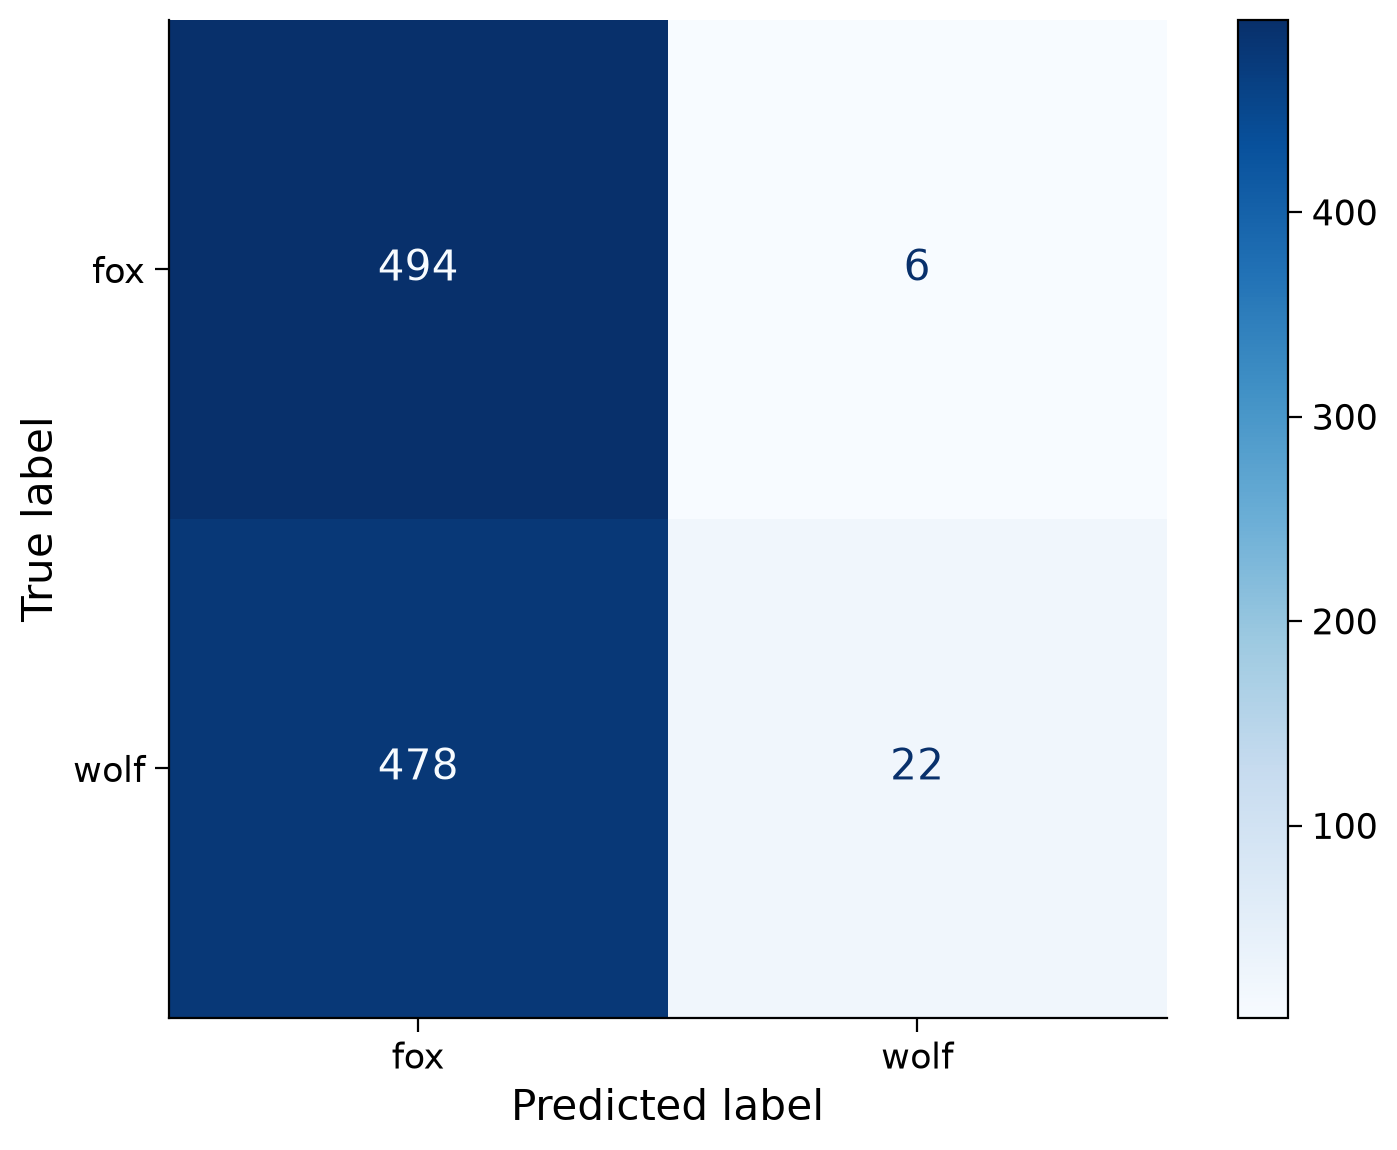

In [31]:
def plotConfusionMatrix(real_labels, predicted_labels, class_names):
    cm = metrics.confusion_matrix(real_labels, predicted_labels)
    metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.show()

plotConfusionMatrix(occ_results['real_labels'], occ_results['predicted_labels'], label_names)

---
# Step 8: Modeling completion

Are we done yet? In order to answer our questions, reach our goals and evaluate our hypotheses we need to run each **model** (CNN / ResNet18) under each **training condition** (regular / occluded, with / without augmentation) and evaluate on clean and occluded test sets. We wrap the whole train+test procedure in one function:

In [32]:
def testOcclusionModel(model_name='cnn',
                       train_occlusion=None,
                       augment=False,
                       test_occlusions=(None, 'small', 'medium', 'large'),
                       num_epochs=10,
                       batch_size=128,
                       learning_rate=0.001,
                       verbose=True):
    """
    Train one binary classifier model on a given condition and evaluate on test conditions.
    """
    # 1. Create training dataset and loader
    ds_train = OccludedMammalDataset(train=True, occlusion=train_occlusion, augment=augment)
    train_loader = DataLoader(dataset=ds_train, batch_size=batch_size, shuffle=True)

    # 2. Instantiate model architecture
    if model_name == 'cnn':
        model = FoxDetectorCNN().to(device)
    elif model_name == 'resnet18':
        model = resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 1)
        model = model.to(device)
    else:
        raise ValueError(f"Unknown model architecture: {model_name}")

    # 3. Loss & Optimizer (Binary Classification)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # 4. Training Loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            binary_labels = (labels == 0).float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, binary_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        if verbose and (epoch + 1) % 2 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}] - Loss: {running_loss / len(train_loader):.4f}")

    # 5. Evaluation Loop across test occlusions
    results = {}
    model.eval()
    for occ in test_occlusions:
        ds_test = OccludedMammalDataset(train=False, occlusion=occ, seed=42)
        test_loader = DataLoader(dataset=ds_test, batch_size=batch_size, shuffle=False)
        
        acc, real_labels, pred_labels = evaluateModelBinary(model, test_loader)
        cond_label = "Clean" if occ is None else f"Occluded ({occ.capitalize()})"
        results[cond_label] = {
            'accuracy': acc,
            'real_labels': real_labels,
            'predicted_labels': pred_labels
        }
        if verbose:
            print(f"  --> Test Accuracy [{cond_label:20s}]: {acc:.2f}%")

    return model, results

Let's test this on one quick condition:

**Each call trains a full model — a few minutes on CPU, faster on GPU.**

In [33]:
fit = testOcclusionModel(model_name='cnn', train_occlusion=None, augment=False,
                         test_occlusions=(None, 'medium'), num_epochs=5)
plotConfusionMatrix(fit['results']['medium']['real_labels'],
                    fit['results']['medium']['predicted_labels'],
                    label_names)

NameError: name 'OccludedMammalDataset' is not defined

* Can we answer our question? --> YES, we can measure the performance drop caused by occlusion.
* Have we reached our goals? --> Almost — we still need the full comparison grid.
* Can we evaluate our hypotheses? --> YES, we can now run all conditions and compare them.

Good news, looks like we're done with a first iteration of modeling!

---
# Step 9: Model evaluation

We can now run the full experiment grid from the project doc (Steps 1-5): both models, trained on regular vs occluded data, without and with augmentation — always evaluated on clean and occluded test sets.

**This trains 8 models — expect it to take a while! (Use a GPU, and/or lower `num_epochs` for a quick pass.)**

In [ ]:
conditions = {
    '1: CNN / regular':            dict(model_name='cnn',      train_occlusion=None,     augment=False),
    '2: CNN / occluded':           dict(model_name='cnn',      train_occlusion='medium', augment=False),
    '3: ResNet18 / regular':       dict(model_name='resnet18', train_occlusion=None,     augment=False),
    '4: ResNet18 / occluded':      dict(model_name='resnet18', train_occlusion='medium', augment=False),
    '5a: CNN / occluded + aug':    dict(model_name='cnn',      train_occlusion='medium', augment=True),
    '5b: ResNet18 / occluded + aug': dict(model_name='resnet18', train_occlusion='medium', augment=True),
}

condition_fits = {}
for name, cfg in conditions.items():
  print(f"\n*** FITTING: {name}")
  t0 = time.time()
  condition_fits[name] = testOcclusionModel(test_occlusions=(None, 'medium'), **cfg)
  print(f"  ({time.time() - t0:.0f} s)")

And how does **occlusion size and type** matter (question 2)? We take one trained model and stress-test it across all occlusion conditions:

In [ ]:
print('Effect of occlusion size/type on the CNN trained on regular data:')
size_sweep = testOcclusionModel(model_name='cnn', train_occlusion=None, augment=False,
                                test_occlusions=(None, 'small', 'medium', 'large', 'gridmask'))

In [ ]:
# summary table of the full grid:
print(f"{'condition':<32} {'clean acc':>10} {'occl acc':>10} {'occl prec':>10}")
for name, fit in condition_fits.items():
  r = fit['results']
  print(f"{name:<32} {r['None']['accuracy']:>9.2f}% {r['medium']['accuracy']:>9.2f}% "
        f"{r['medium']['precision']:>9.2f}%")

Things to look for (our hypotheses):

* **H1**: within each row, is the occluded-test accuracy lower than the clean-test accuracy? Does the drop grow with occlusion size in the sweep?
* **H2**: do the `+ aug` rows recover accuracy/precision on the occluded test set compared to their non-augmented counterparts?
* **H3**: does ResNet18 beat the CNN in every condition?

For a formal test, fit each condition several times (different seeds) and compare medians — single runs are noisy.

---
# Step 10: publication

Let's write a simple abstract following the guidelines...

**A. What is the phenomena?** Here summarize the part of the phenomena which your modeling addresses.

*Occlusion — the partial obstruction of an object's visible surface — deprives vision models of evidence and degrades recognition.*

**B. What is the key scientific question?** Clearly articulate the question which your modeling tries to answer.

*Here, we ask how occlusion size and type affect the performance of image-classification models, and whether data augmentation mitigates these effects.*

**C. What was our hypothesis?** Explain the key relationships which we relied on to simulate the phenomena.

*We hypothesized that occlusion degrades performance (more so for larger occlusions), that augmentation reduces this degradation, and that ResNet18 outperforms a simple CNN even under occlusion.*

**D. How did your modeling work?** Give an overview of the model, its main components, and how the modeling works.

*We trained a simple CNN and a ResNet18 on the mammal classes of CIFAR-100, with and without simulated occlusion (Cutout-style blocks of varying size, GridMask) and with and without augmentation (geometric transforms and Random Erasing), and evaluated confusion matrices and precision on clean and occluded test sets.*

**E. What did you find? Did the modeling work?** Explain the key outcomes of your modeling evaluation.

*TODO — fill in after running Step 9.*

**F. What can you conclude?** Conclude as much as you can with reference to the hypothesis, within the limits of the modeling.

*TODO*

**G. What are the limitations and future directions?** What is left to be learned?

*Our occlusions are synthetic and may not capture natural occlusion statistics; CIFAR images are small (32x32); results may be architecture-specific. Future work: Faster R-CNN / YOLO on occluded detection tasks, segmentation masks, and body-part-specific occlusion with DeepLabCut.*

>Put this all in one paragraph (without the letters) for the final abstract.